In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = kagglehub.dataset_download("dhairyajeetsingh/ecommerce-customer-behavior-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 1.96M/1.96M [00:00<00:00, 69.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/versions/1
['ecommerce_customer_churn_dataset.csv']


In [2]:
file_path = os.path.join(path, "ecommerce_customer_churn_dataset.csv")
df = pd.read_csv(file_path)

print(df.head())

    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9                     9.0   
1     

## Data Cleaning

In [3]:
df.isnull().sum()
null_percent = df.isnull().mean() * 100
print(null_percent.sort_values(ascending=False))

Social_Media_Engagement_Score    12.000
Credit_Balance                   11.000
Mobile_App_Usage                 10.000
Returns_Rate                      8.982
Wishlist_Items                    8.000
Product_Reviews_Written           7.000
Discount_Usage_Rate               7.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Days_Since_Last_Purchase          6.000
Email_Open_Rate                   5.056
Payment_Method_Diversity          5.000
Age                               4.990
Customer_Service_Calls            0.336
Gender                            0.000
Country                           0.000
Membership_Years                  0.000
Cart_Abandonment_Rate             0.000
Login_Frequency                   0.000
City                              0.000
Average_Order_Value               0.000
Total_Purchases                   0.000
Lifetime_Value                    0.000
Churned                           0.000
Signup_Quarter                    0.000


In [4]:
#1-5%
columns_to_impute = ['Customer_Service_Calls', 'Age', 'Payment_Method_Diversity', 'Email_Open_Rate']
for col in columns_to_impute:
    df[col] = df[col].fillna(df[col].median())

#5-10%
df['Activity_Tier'] = pd.qcut(df['Login_Frequency'], q=5, labels=[1, 2, 3, 4, 5])
column_to_impute1 = ['Session_Duration_Avg', 'Product_Reviews_Written', 'Wishlist_Items', 'Pages_Per_Session']
for col in column_to_impute1:
    df[col] = df.groupby('Activity_Tier', observed=False)[col].transform(lambda x: x.fillna(x.median()))

df['Membership_Tier'] = pd.qcut(df['Membership_Years'], q=3, labels=['New_User', 'Regular_User', 'Loyal_User'])
df['Discount_Usage_Rate'] = df.groupby('Membership_Tier', observed=False)['Discount_Usage_Rate'].transform(lambda x: x.fillna(x.median()))
df['Returns_Rate'] = df.groupby('Customer_Service_Calls')['Returns_Rate'].transform(lambda x: x.fillna(x.median()))
df['Days_Since_Last_Purchase'] = df.groupby('Churned')['Days_Since_Last_Purchase'].transform(lambda x: x.fillna(x.median()))

#10-12%
df['SM_missing'] = df['Social_Media_Engagement_Score'].isnull().astype(int)
df['App_missing'] = df['Mobile_App_Usage'].isnull().astype(int)
df['Credit_missing'] = df['Credit_Balance'].isnull().astype(int)

high_missing_cols = ['Social_Media_Engagement_Score', 'Mobile_App_Usage']
for col in high_missing_cols:
    df[col] = df.groupby('Activity_Tier', observed=False)[col].transform(lambda x: x.fillna(x.median()))

df['Credit_Balance'] = df['Credit_Balance'].fillna(0)

df.drop(columns=['Membership_Tier'], inplace=True)
df.drop(columns=['Activity_Tier'], inplace=True)


In [5]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,SM_missing,App_missing,Credit_missing
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.812800,2.984009,11.624660,27.353578,8.735973,57.079973,4.282880,13.111576,123.117330,29.269060,...,2.835320,29.237210,19.363318,2.33618,1440.626292,1749.947600,0.289000,0.120000,0.100000,0.110000
std,11.535688,2.059105,7.810657,10.647001,3.711174,16.282723,3.097672,7.017312,175.569714,28.875553,...,2.275044,19.760739,9.149380,1.08465,907.249443,1309.277071,0.453302,0.324965,0.300003,0.312893
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,19.400000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,1.000000,13.600000,12.600000,2.00000,789.817500,647.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,2.500000,11.000000,26.400000,8.400000,58.100000,4.000000,12.000000,112.970000,20.000000,...,2.000000,27.200000,18.600000,2.00000,1243.415000,1697.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,4.000000,17.000000,34.100000,11.100000,68.700000,6.000000,17.000000,144.440000,39.000000,...,4.000000,42.500000,25.300000,3.00000,1874.000000,2664.000000,1.000000,0.000000,0.000000,0.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,21.000000,100.000000,61.900000,5.00000,8987.240000,7197.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df = df[(df['Age'] >= 12) & (df['Age'] <= 90)]
df = df[df['Total_Purchases'] >= 0]
df = df[df['Cart_Abandonment_Rate'] <= 100]

# Tangani Outlier AOV menggunakan metode memangkas nilai ekstrem (1% teratas)
q_high = df['Average_Order_Value'].quantile(0.99)
df = df[df['Average_Order_Value'] < q_high]


In [7]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,SM_missing,App_missing,Credit_missing
count,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,...,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000,49381.000000
mean,37.782609,2.982930,11.630202,27.361710,8.740392,57.033229,4.286365,13.131654,117.821935,29.279439,...,2.835119,29.258267,19.372176,2.336769,1422.655186,1751.163747,0.286527,0.119884,0.100099,0.109921
std,11.165671,2.057075,7.814457,10.651151,3.710558,16.213993,3.099529,7.006998,41.548701,28.881621,...,2.275388,19.760663,9.150139,1.084740,880.057217,1309.993017,0.452143,0.324829,0.300135,0.312794
min,18.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,19.400000,6.000000,46.400000,2.000000,8.000000,86.780000,9.000000,...,1.000000,13.600000,12.600000,2.000000,785.250000,648.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,2.500000,11.000000,26.400000,8.400000,58.100000,4.000000,12.000000,112.380000,20.000000,...,2.000000,27.200000,18.600000,2.000000,1234.020000,1699.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,4.000000,17.000000,34.200000,11.100000,68.700000,6.000000,17.000000,143.230000,39.000000,...,4.000000,42.500000,25.300000,3.000000,1856.250000,2665.000000,1.000000,0.000000,0.000000,0.000000
max,75.000000,10.000000,46.000000,75.600000,24.100000,100.000000,28.000000,128.700000,252.020000,287.000000,...,21.000000,100.000000,61.900000,5.000000,8023.200000,7197.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.to_csv('customer_behav.csv', index=False)

## User Behavior

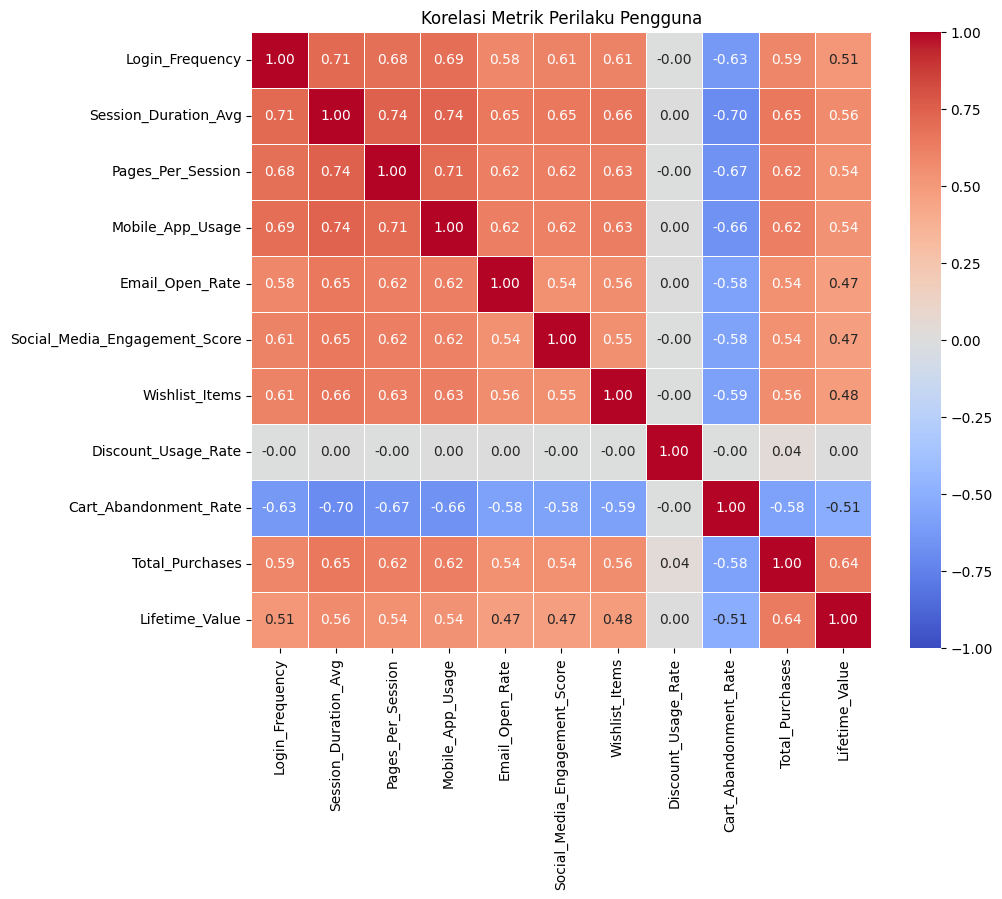

In [8]:
behavior_metrics = ['Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Mobile_App_Usage',
    'Email_Open_Rate',
    'Social_Media_Engagement_Score',
    'Wishlist_Items',
    'Discount_Usage_Rate',
    'Cart_Abandonment_Rate',
    'Total_Purchases',
    'Lifetime_Value']
correlation_matrix = df[behavior_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Metrik Perilaku Pengguna')
plt.show()

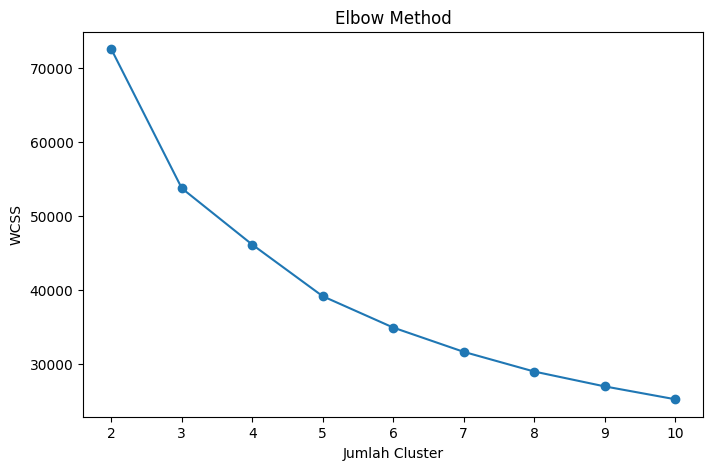

              Login_Frequency  Session_Duration_Avg  Total_Purchases  \
User_Segment                                                           
Segment 1                5.08                 18.36             8.06   
Segment 2               13.37                 29.56            14.02   
Segment 3               22.47                 42.66            22.53   

              Lifetime_Value  Days_Since_Last_Purchase  Cart_Abandonment_Rate  \
User_Segment                                                                    
Segment 1             889.75                     28.95                  68.00   
Segment 2            1546.83                     29.55                  54.60   
Segment 3            2341.77                     29.42                  37.85   

              Churned  
User_Segment           
Segment 1        0.40  
Segment 2        0.21  
Segment 3        0.20  


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

behavior_features = ['Login_Frequency', 'Session_Duration_Avg', 'Total_Purchases',]
X = df[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['User_Segment'] = kmeans.fit_predict(X_scaled)

segment_mapping = {0: 'Segment 1', 1: 'Segment 2', 2: 'Segment 3'}
df['User_Segment'] = df['User_Segment'].map(segment_mapping)

segment_profile = df.groupby('User_Segment')[['Login_Frequency', 'Session_Duration_Avg', 'Total_Purchases', 'Lifetime_Value', 'Days_Since_Last_Purchase', 'Cart_Abandonment_Rate', 'Churned']].mean()
print(segment_profile.round(2))

In [13]:
segment_mapping = {'Segment 1':'Low Activity User', 'Segment 2':'Moderately Active Users', 'Segment 3':'High Activity Users'}
df['User_Segment'] = df['User_Segment'].replace(segment_mapping)

In [14]:
df['User_Segment'].value_counts()

,count
User_Segment,
Low Activity User,20363
Moderately Active Users,19900
High Activity Users,9118


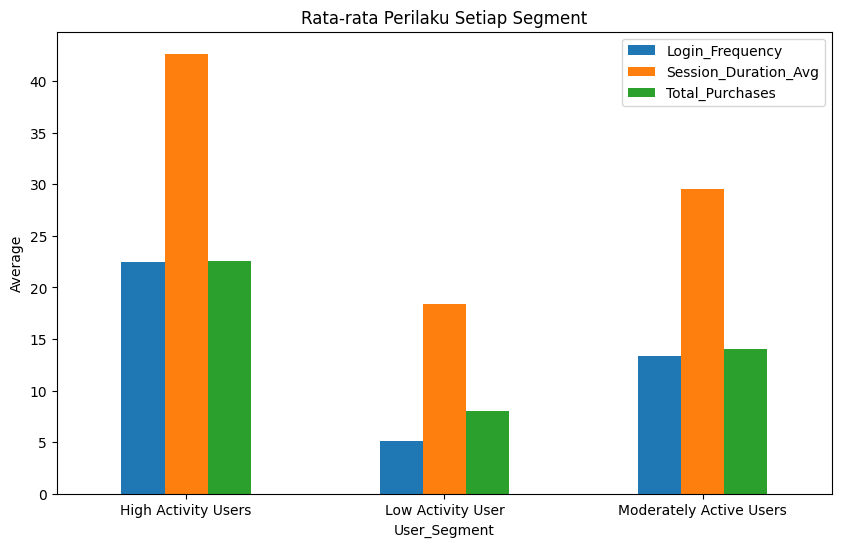

In [15]:
profile = df.groupby('User_Segment')[
    behavior_features
].mean()

profile.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Rata-rata Perilaku Setiap Segment")
plt.ylabel("Average")
plt.xticks(rotation=0)
plt.show()

In [16]:
churn_segment = df.groupby('User_Segment')['Churned'].mean()*100

print(churn_segment.round(2))

User_Segment
High Activity Users        19.65
Low Activity User          39.88
Moderately Active Users    21.29
Name: Churned, dtype: float64


In [17]:
ltv_segment = df.groupby('User_Segment')[
    'Lifetime_Value'
].mean()

print(ltv_segment)

User_Segment
High Activity Users        2341.765560
Low Activity User           889.753544
Moderately Active Users    1546.827434
Name: Lifetime_Value, dtype: float64
